# Driver Churn Analysis: Hypothesis Testing

**Dataset:** `data/churn.csv` — Driver activity records from a ride-hailing service (Uber-like)

**Context:** The company wants to understand driver churn — which drivers are leaving the platform and why.
The goal is to formulate and test hypotheses, identify driver segments most prone to churn, and derive
actionable insights that can later be validated via an A/B test.

**Topics:**
1. Dataset overview and preprocessing
2. Churn definition and distribution
3. Hypothesis 1 — Does phone type predict churn? (Chi-square)
4. Hypothesis 2 — Does churn rate differ by city? (Chi-square)
5. Hypothesis 3 — Does early activity differ by city? (Kruskal-Wallis)
6. Hypothesis 4 — Are churned drivers less active early on? (Mann-Whitney U)
7. Summary and next steps

## Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `city` | str | City where the driver operates |
| `phone` | str | Primary device used by the driver (`iPhone` / `Android`) |
| `signup_date` | date | Account registration date |
| `last_trip_date` | date | Date of the most recent trip |
| `avg_dist` | float | Average trip distance (miles) in the first 30 days |
| `avg_rating_by_driver` | float | Average rating the driver gave to riders |
| `avg_rating_of_driver` | float | Average rating riders gave to the driver |
| `surge_pct` | float | % of trips taken with surge multiplier > 1 |
| `avg_surge` | float | Average surge multiplier across all trips |
| `trips_in_first_30_days` | int | Number of trips completed in the first 30 days after signup |
| `luxury_car_user` | bool | `True` if the driver used a luxury car in the first 30 days |
| `weekday_pct` | float | % of trips taken on weekdays |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro
import pingouin as pg

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Overview

In [2]:
df = pd.read_csv('data/churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 12)


,avg_dist,avg_rating_by_driver,avg_rating_of_driver,avg_surge,city,last_trip_date,phone,signup_date,surge_pct,trips_in_first_30_days,luxury_car_user,weekday_pct
0,3.67,5.0,4.7,1.10,King's Landing,2014-06-17,iPhone,2014-01-25,15.4,4,True,46.2
1,8.26,5.0,5.0,1.00,Astapor,2014-05-05,Android,2014-01-29,0.0,0,False,50.0
2,0.77,5.0,4.3,1.00,Astapor,2014-01-07,iPhone,2014-01-06,0.0,3,False,100.0
3,2.36,4.9,4.6,1.14,King's Landing,2014-06-29,iPhone,2014-01-10,20.0,9,True,80.0
4,3.13,4.9,4.4,1.19,Winterfell,2014-03-15,Android,2014-01-27,11.8,14,False,82.4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   avg_dist                50000 non-null  float64
 1   avg_rating_by_driver    49799 non-null  float64
 2   avg_rating_of_driver    41878 non-null  float64
 3   avg_surge               50000 non-null  float64
 4   city                    50000 non-null  str    
 5   last_trip_date          50000 non-null  str    
 6   phone                   49604 non-null  str    
 7   signup_date             50000 non-null  str    
 8   surge_pct               50000 non-null  float64
 9   trips_in_first_30_days  50000 non-null  int64  
 10  luxury_car_user         50000 non-null  bool   
 11  weekday_pct             50000 non-null  float64
dtypes: bool(1), float64(6), int64(1), str(4)
memory usage: 4.2 MB


In [4]:
df.isna().sum()

avg_dist                     0
avg_rating_by_driver       201
avg_rating_of_driver      8122
avg_surge                    0
city                         0
last_trip_date               0
phone                      396
signup_date                  0
surge_pct                    0
trips_in_first_30_days       0
luxury_car_user              0
weekday_pct                  0
dtype: int64

In [5]:
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
df['signup_date']    = pd.to_datetime(df['signup_date'])

print(df[['last_trip_date', 'signup_date']].describe())

                   last_trip_date                 signup_date
count                       50000                       50000
mean   2014-04-19 08:02:04.992000  2014-01-16 13:04:20.352000
min           2014-01-01 00:00:00         2014-01-01 00:00:00
25%           2014-02-14 00:00:00         2014-01-09 00:00:00
50%           2014-05-08 00:00:00         2014-01-17 00:00:00
75%           2014-06-18 00:00:00         2014-01-24 00:00:00
max           2014-07-01 00:00:00         2014-01-31 00:00:00


In [6]:
df[['city', 'phone']].describe()

,city,phone
count,50000,49604
unique,3,2
top,Winterfell,iPhone
freq,23336,34582


## 2. Defining Churn

**Churn rate** measures how many active users stop using a service over a given period.
It is the inverse of retention rate: $\text{churn rate} = 1 - \text{retention rate}$.

We define a driver as **churned** if they have not completed a trip in the **last 30 days**
relative to the most recent trip date in the dataset (`2014-07-01`).

This is a common proxy when there is no explicit "account closed" event.

In [7]:
reference_date = df['last_trip_date'].max()
df['days_since_last_trip'] = (reference_date - df['last_trip_date']).dt.days
df['churn'] = df['days_since_last_trip'].apply(lambda x: 'churned' if x > 30 else 'retained')

churn_rates = df['churn'].value_counts(normalize=True).mul(100).round(1)
print(churn_rates.to_string())

churn
churned     62.4
retained    37.6


/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_45279/3630209398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['tomato', 'steelblue'])


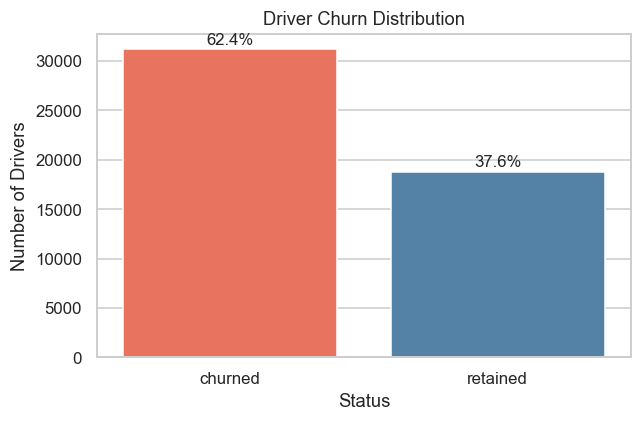


~62% of drivers are classified as churned (no trip in the last 30 days).


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['churn'].value_counts()
bars = sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['tomato', 'steelblue'])

for bar, (label, pct) in zip(bars.patches, churn_rates.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{pct}%', ha='center', va='bottom', fontsize=11
    )

ax.set_title('Driver Churn Distribution')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Drivers')
plt.tight_layout()
plt.show()

print(f'\n~{churn_rates["churned"]:.0f}% of drivers are classified as churned (no trip in the last 30 days).')

## 3. Hypothesis Testing

We test four hypotheses about what drives churn. The choice of test depends on the variable types:

| Variable types | Recommended test |
|---------------|------------------|
| Two categorical variables | Chi-square ($\chi^2$) test of independence |
| One categorical (2 groups), one continuous (non-normal) | Mann-Whitney U test |
| One categorical (3+ groups), one continuous (non-normal) | Kruskal-Wallis test |

Significance level: $\alpha = 0.05$

### Hypothesis 1: Churn vs Phone Type

**Motivation:** Churn could stem from a technical bug affecting one platform.
Before designing any product change, it is important to rule out device-specific issues.
If Android users churn significantly more, the root cause may be a technical problem rather than a product issue.

Both variables are **categorical** → **Chi-square test of independence**.

- $H_0$: Churn is independent of phone type  
- $H_1$: There is a significant association between churn and phone type

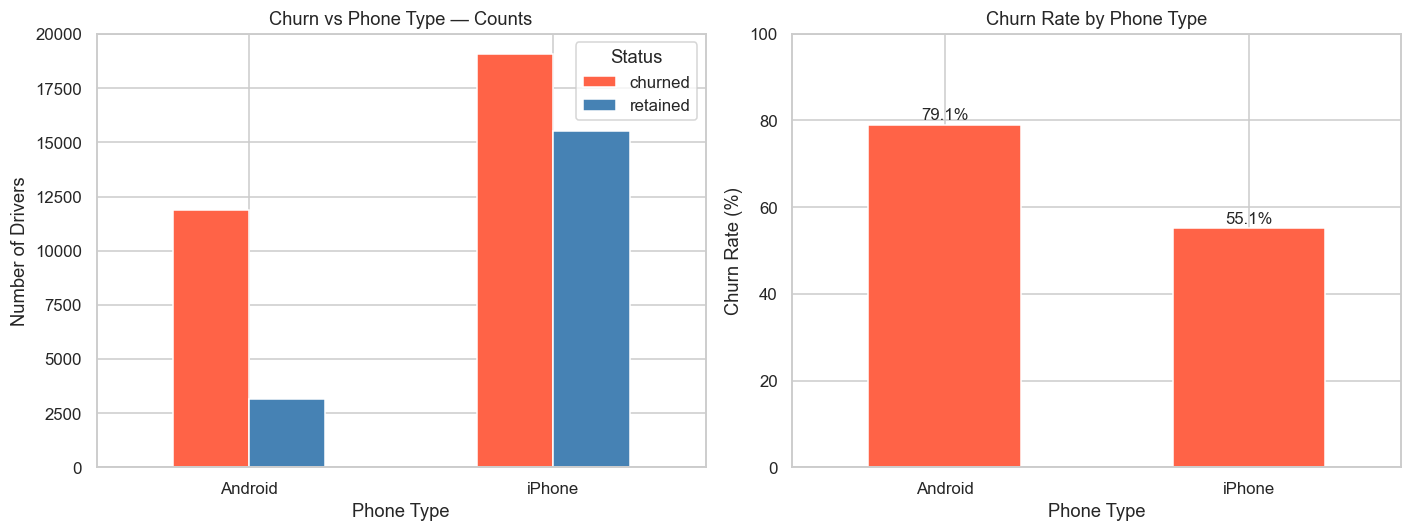

In [9]:
# Stacked bar chart — churn rate per phone type
phone_churn = (
    df.dropna(subset=['phone'])
      .groupby(['phone', 'churn'])
      .size()
      .unstack()
      .assign(total=lambda x: x.sum(axis=1))
      .assign(churned_pct=lambda x: x['churned'] / x['total'] * 100,
              retained_pct=lambda x: x['retained'] / x['total'] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute counts
phone_churn[['churned', 'retained']].plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'], rot=0)
axes[0].set_title('Churn vs Phone Type — Counts')
axes[0].set_xlabel('Phone Type')
axes[0].set_ylabel('Number of Drivers')
axes[0].legend(title='Status')

# Churn rate
phone_churn['churned_pct'].plot(kind='bar', ax=axes[1], color='tomato', rot=0)
for i, v in enumerate(phone_churn['churned_pct']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Churn Rate by Phone Type')
axes[1].set_xlabel('Phone Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [10]:
contingency = pd.crosstab(df['churn'], df['phone'])
print('Contingency table:')
print(contingency)

stat, p, dof, expected = chi2_contingency(contingency)

print(f'\nChi-square statistic: {stat:.2f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p:.4e}')
print(f"\n=> {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} (α = 0.05)")
print('Conclusion: Churn rate IS significantly associated with phone type.')
print('Android drivers churn at a higher rate — worth investigating for platform-specific bugs.')

Contingency table:
phone     Android  iPhone
churn                    
churned     11876   19057
retained     3146   15525

Chi-square statistic: 2558.39
Degrees of freedom:   1
P-value:              0.0000e+00

=> Reject H₀ (α = 0.05)
Conclusion: Churn rate IS significantly associated with phone type.
Android drivers churn at a higher rate — worth investigating for platform-specific bugs.


### Hypothesis 2: Churn vs City

**Motivation:** Churn patterns may differ by geography — local competition, market saturation,
or city-specific service issues could drive different retention outcomes.

Both variables are **categorical** → **Chi-square test of independence**.

- $H_0$: Churn is independent of city  
- $H_1$: Churn rate differs significantly across cities

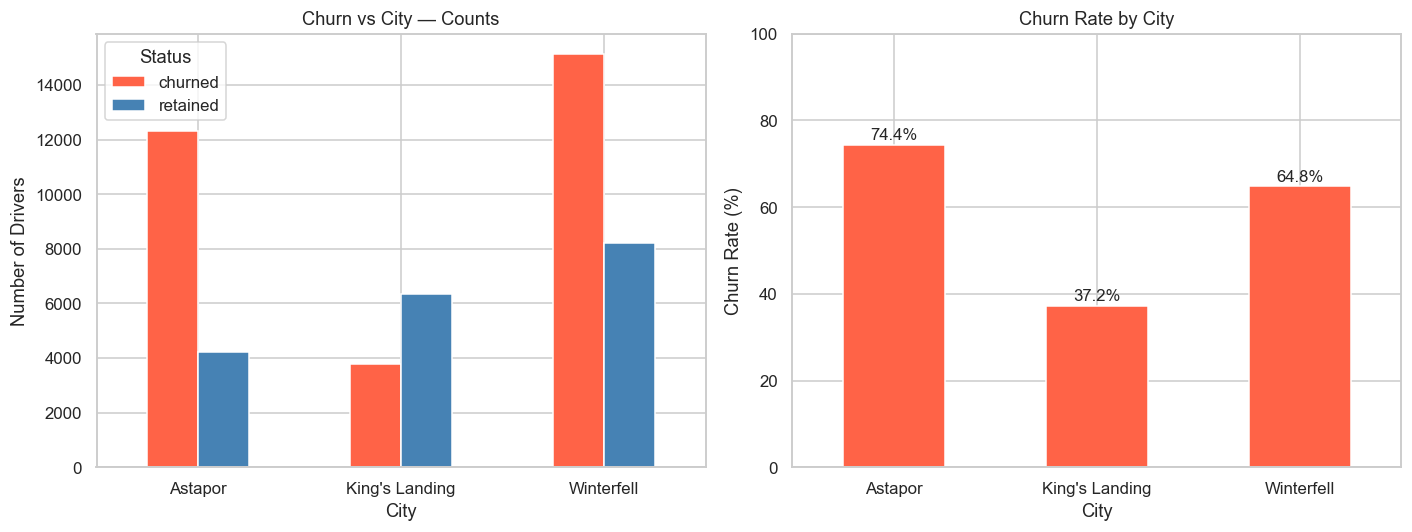

In [11]:
city_churn = (
    df.groupby(['city', 'churn'])
      .size()
      .unstack()
      .assign(total=lambda x: x.sum(axis=1))
      .assign(churned_pct=lambda x: x['churned'] / x['total'] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

city_churn[['churned', 'retained']].plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'], rot=0)
axes[0].set_title('Churn vs City — Counts')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of Drivers')
axes[0].legend(title='Status')

city_churn['churned_pct'].plot(kind='bar', ax=axes[1], color='tomato', rot=0)
for i, v in enumerate(city_churn['churned_pct']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title("Churn Rate by City")
axes[1].set_xlabel('City')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [15]:
contingency_city = pd.crosstab(df['churn'], df['city'])
print('Contingency table:')
print(contingency_city)

stat, p, dof, expected = chi2_contingency(contingency_city)

print(f'\nChi-square statistic: {stat:.2f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p:.4e}')
print(f"\n=> {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} (α = 0.05)")
print('Conclusion: Churn rate IS significantly different across cities.')
print("Astapor shows the highest churn rate — city-level analysis is warranted.")

Contingency table:
city      Astapor  King's Landing  Winterfell
churn                                        
churned     12306            3767       15123
retained     4228            6363        8213

Chi-square statistic: 3821.55
Degrees of freedom:   2
P-value:              0.0000e+00

=> Reject H₀ (α = 0.05)
Conclusion: Churn rate IS significantly different across cities.
Astapor shows the highest churn rate — city-level analysis is warranted.


### Hypothesis 3: Early Activity vs City

**Motivation:** Driver onboarding experience may vary by city. If drivers in some cities make
significantly fewer trips in their first 30 days, that may signal weaker onboarding or demand in those markets.

Variable types: **categorical** (city) + **continuous** (`trips_in_first_30_days`).

We first check normality. For large samples, we use **D'Agostino-Pearson test** via `pingouin`
(more reliable than Shapiro-Wilk for $n > 5000$). If normality fails → **Kruskal-Wallis test** (non-parametric ANOVA).

- $H_0$: Early trip counts are identically distributed across all three cities  
- $H_1$: At least one city differs significantly

In [17]:
# Normality check (D'Agostino-Pearson — designed for large samples)
print("Normality test (D'Agostino-Pearson):")
print(pg.normality(data=df, dv='trips_in_first_30_days', group='city', method='normaltest'))

# Variance homogeneity check (Levene test)
print('\nHomoscedasticity test (Levene):')
print(pg.homoscedasticity(data=df, dv='trips_in_first_30_days', group='city'))

Normality test (D'Agostino-Pearson):
                           W  pval  normal
city                                      
King's Landing  12011.013892   0.0   False
Astapor         18186.739338   0.0   False
Winterfell      21390.545655   0.0   False

Homoscedasticity test (Levene):
                W          pval  equal_var
levene  98.098728  3.017436e-43      False


/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_45279/3689672582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_45279/3689672582.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


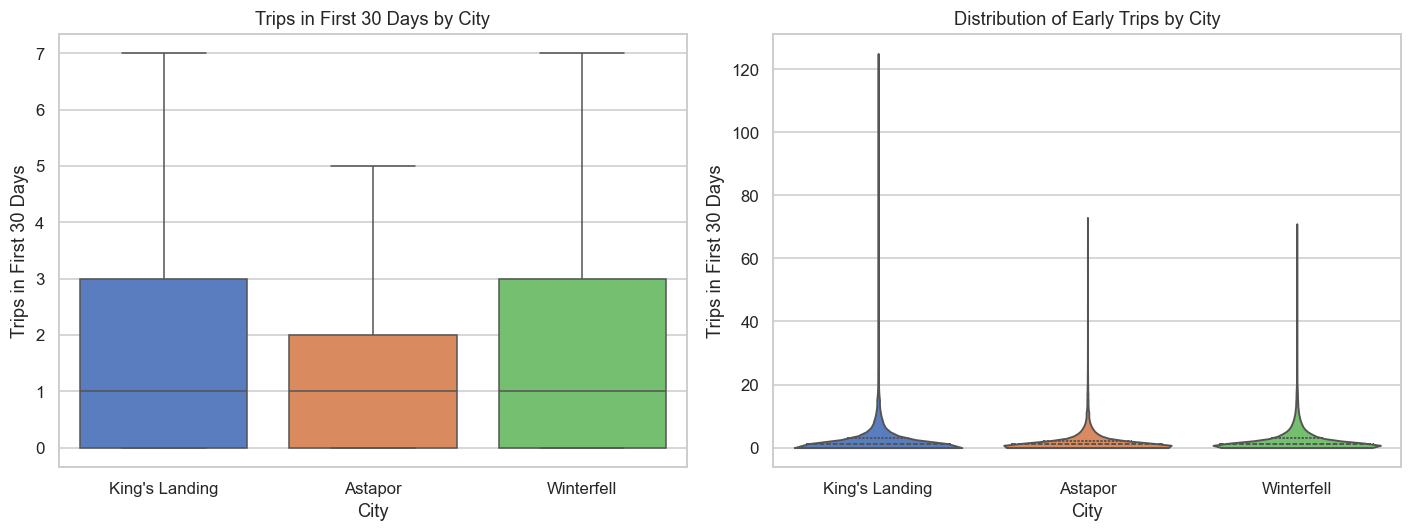

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df, x='city', y='trips_in_first_30_days',
    ax=axes[0], palette='muted', showfliers=False
)
axes[0].set_title('Trips in First 30 Days by City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Trips in First 30 Days')

sns.violinplot(
    data=df, x='city', y='trips_in_first_30_days',
    ax=axes[1], palette='muted', inner='quartile', cut=0
)
axes[1].set_title('Distribution of Early Trips by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Trips in First 30 Days')

plt.tight_layout()
plt.show()

In [19]:
kings      = df[df['city'] == "King's Landing"]['trips_in_first_30_days']
astapor    = df[df['city'] == 'Astapor']['trips_in_first_30_days']
winterfell = df[df['city'] == 'Winterfell']['trips_in_first_30_days']

stat, p = ss.kruskal(kings, astapor, winterfell)

print('Group medians:')
for city, grp in df.groupby('city')['trips_in_first_30_days']:
    print(f'  {city:<20} median={grp.median():.1f}  mean={grp.mean():.2f}')

print(f'\nKruskal-Wallis statistic: {stat:.2f}')
print(f'P-value:                  {p:.4e}')
print(f"\n=> {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} (α = 0.05)")
print('Conclusion: Early activity levels differ significantly across cities.')

Group medians:
  Astapor              median=1.0  mean=1.95
  King's Landing       median=1.0  mean=2.46
  Winterfell           median=1.0  mean=2.43

Kruskal-Wallis statistic: 221.32
P-value:                  8.7246e-49

=> Reject H₀ (α = 0.05)
Conclusion: Early activity levels differ significantly across cities.


### Hypothesis 4: Churn vs Early Activity

**Motivation:** A common churn signal is low engagement during onboarding.
Drivers who make few trips in their first 30 days may not have fully adopted the platform.

Variable types: **binary categorical** (churn) + **continuous** (`trips_in_first_30_days`).

If the distribution is non-normal → **Mann-Whitney U test** (non-parametric alternative to independent samples T-test).
The Mann-Whitney U test checks whether values from one group **tend to be larger** than the other.

- $H_0$: Early trip counts have the same distribution for churned and retained drivers  
- $H_1$: Churned drivers made significantly fewer trips in the first 30 days

In [20]:
churn_grp    = df.query("churn == 'churned'")['trips_in_first_30_days']
retained_grp = df.query("churn == 'retained'")['trips_in_first_30_days']

# Normality check on 1000-sample (Shapiro-Wilk unreliable on full data)
print('Shapiro-Wilk normality test (sample n=1000):')
print(f'  churned:  p = {ss.shapiro(churn_grp.sample(1000, random_state=17)).pvalue:.4e}')
print(f'  retained: p = {ss.shapiro(retained_grp.sample(1000, random_state=17)).pvalue:.4e}')
print('\nBoth groups are far from normal — Mann-Whitney U test is appropriate.')

Shapiro-Wilk normality test (sample n=1000):
  churned:  p = 1.1746e-47
  retained: p = 3.3916e-41

Both groups are far from normal — Mann-Whitney U test is appropriate.


/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_45279/94216967.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='trips_in_first_30_days', ax=axes[1],


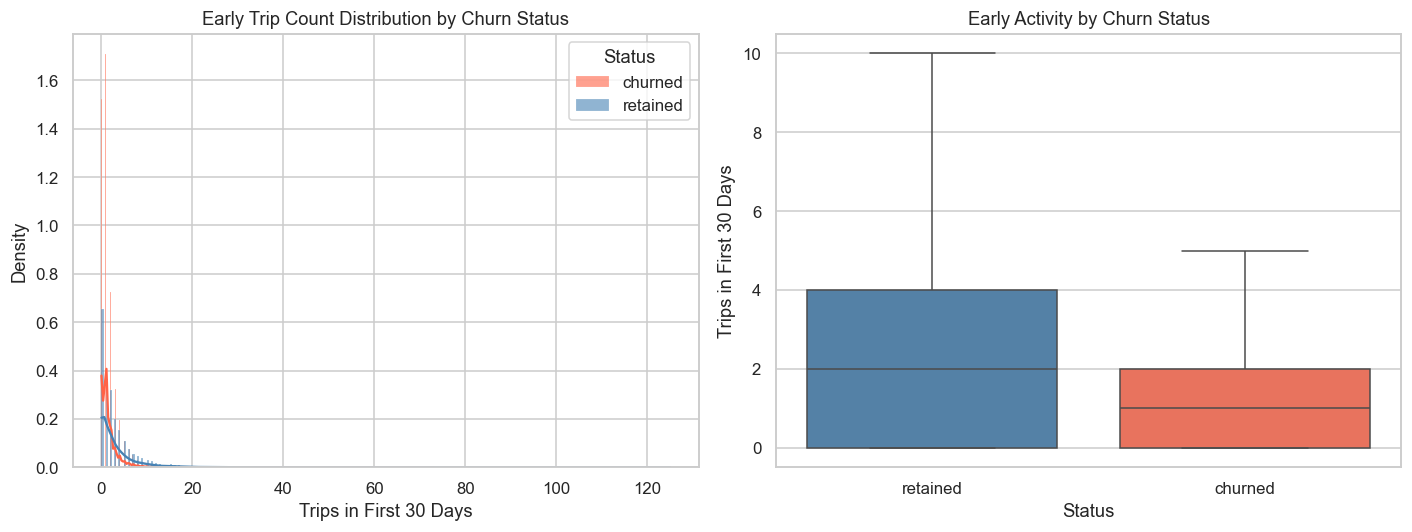

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution comparison
for label, grp, color in [('churned', churn_grp, 'tomato'), ('retained', retained_grp, 'steelblue')]:
    sns.histplot(grp, ax=axes[0], label=label, color=color, alpha=0.6, kde=True, stat='density')
axes[0].set_title('Early Trip Count Distribution by Churn Status')
axes[0].set_xlabel('Trips in First 30 Days')
axes[0].legend(title='Status')

# Boxplot
sns.boxplot(data=df, x='churn', y='trips_in_first_30_days', ax=axes[1],
            palette={'churned': 'tomato', 'retained': 'steelblue'},
            showfliers=False)
axes[1].set_title('Early Activity by Churn Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Trips in First 30 Days')

plt.tight_layout()
plt.show()

In [23]:
result = ss.mannwhitneyu(churn_grp, retained_grp, alternative='less')

print('Descriptive statistics:')
print(df.groupby('churn')['trips_in_first_30_days'].agg(['median', 'mean']).round(2))

print(f'\nMann-Whitney U statistic: {result.statistic:.0f}')
print(f'P-value:                  {result.pvalue:.4e}')
print(f"\n=> {'Reject H₀' if result.pvalue < 0.05 else 'Fail to reject H₀'} (α = 0.05)")
print('Conclusion: Churned drivers made significantly FEWER trips in the first 30 days.')
print('Early activity is a strong predictor of churn.')

Descriptive statistics:
          median  mean
churn                 
churned      1.0  1.66
retained     2.0  3.31

Mann-Whitney U statistic: 234767452
P-value:                  0.0000e+00

=> Reject H₀ (α = 0.05)
Conclusion: Churned drivers made significantly FEWER trips in the first 30 days.
Early activity is a strong predictor of churn.


## Summary & Next Steps

### Key Findings

| # | Hypothesis | Test | Result |
|---|-----------|------|--------|
| 1 | Churn is associated with phone type | Chi-square | **Significant** — Android users churn more |
| 2 | Churn rate differs across cities | Chi-square | **Significant** — Astapor has the highest churn |
| 3 | Early activity differs across cities | Kruskal-Wallis | **Significant** — city-level onboarding varies |
| 4 | Churned drivers are less active early on | Mann-Whitney U | **Significant** — churned drivers make ~2× fewer early trips |

### Recommended Actions

1. **Investigate the Android platform** — the higher churn on Android may indicate a technical bug or UX regression.
   Narrow down by app version, OS version, or signup date cohort before launching an A/B test.

2. **Improve early onboarding** — since low first-30-day activity strongly predicts churn,
   test interventions (welcome bonus, guided first trips, support outreach) targeted at new low-activity drivers.

3. **City-specific strategy for Astapor** — the significantly higher churn rate in Astapor warrants
   a dedicated deep-dive. Possible causes: market saturation, competitor pressure, or local demand issues.

### Next Step: A/B Test Design

Once the root causes are confirmed, each intervention should be validated via a properly designed A/B test:
- Define a primary metric (e.g., 30-day retention rate)
- Perform power analysis to determine required sample size
- Run the experiment for a full business cycle before concluding